## Importing PyTorch and other dependencies
Importing PyTorch and matplot for data visualization.

In [266]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Agnostic Code Setup

In [267]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Data Preparation 

### Data loading
Data loading is done by using pandas library.

In [268]:
import pandas as pd
import torch

df = pd.read_csv(r'./Resources/assignment-data.csv')
df.head(5) #first five data point

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92


## Changing shape of the data for PyTorch 

Pytorch uses Tenors so we need to convert our data into the required multidimensional tensor data structure. 

In order to convert the 1 D vector consisting of scalar data points into tensors, We need to  unsqueeze the data by using the unsqueeze function from pytorch.
Here the output shape of the data shows that its been converted into a tensor of shape (50, 1);where there is 50 data points and a 1 column.

In [269]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


## Splitting data 
We need two data sets; one for training our model and other to test the model, so we split the dataset into two parts.

In [270]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualization of training data
The dataset is visualized as follows.

In [271]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 20});


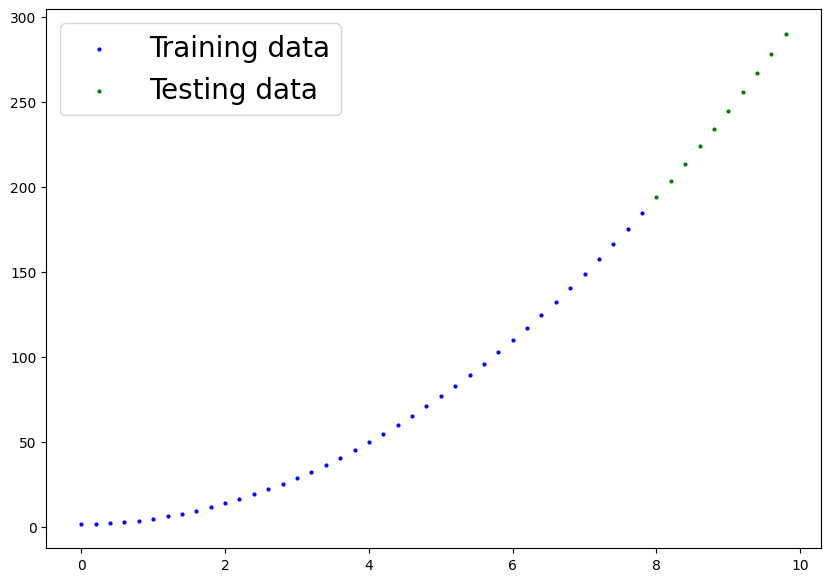

In [272]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Here, the blue dots represent the training dataset and the green dots represent the testing data. The coloured point on the curve here shows that the data has been split correctly into 80% training data and 20% testing data.

</br>

## **Note:**
Its important to note that the data is in a curve and not a line. It shows **quadratic nature.**

## Algorithm Selection
Lets first try Linear Regression to see how the model behaves when its been fed a curve and not a straight line.

### Model and Forward Pass

In [273]:
import torch 
from torch import nn
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + c) or (y= w*x + b)

In [274]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [275]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [276]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

In [277]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917],
        [3.1590],
        [3.2264],
        [3.2937],
        [3.3610],
        [3.4284]])


### Predictions without training

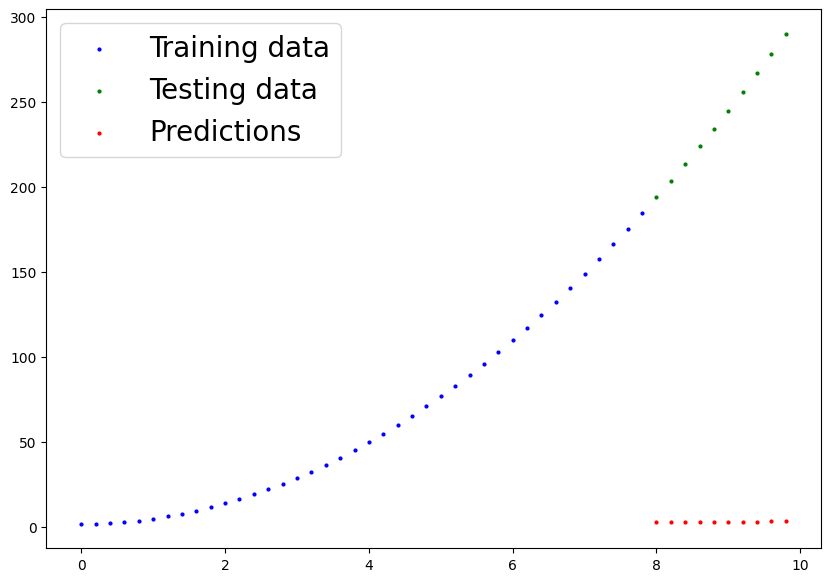

In [278]:
plot_predictions(predictions=y_preds)

In [279]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


In [280]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 62.17809295654297 | MAE Test Loss: 237.13754272460938 
Epoch: 10 | MAE Train Loss: 60.557098388671875 | MAE Test Loss: 233.56655883789062 
Epoch: 20 | MAE Train Loss: 58.93609619140625 | MAE Test Loss: 229.9955596923828 
Epoch: 30 | MAE Train Loss: 57.315101623535156 | MAE Test Loss: 226.424560546875 
Epoch: 40 | MAE Train Loss: 55.694091796875 | MAE Test Loss: 222.853515625 
Epoch: 50 | MAE Train Loss: 54.073097229003906 | MAE Test Loss: 219.2825164794922 
Epoch: 60 | MAE Train Loss: 52.45208740234375 | MAE Test Loss: 215.71151733398438 
Epoch: 70 | MAE Train Loss: 50.831092834472656 | MAE Test Loss: 212.14053344726562 
Epoch: 80 | MAE Train Loss: 49.21009063720703 | MAE Test Loss: 208.5695343017578 
Epoch: 90 | MAE Train Loss: 47.637943267822266 | MAE Test Loss: 205.05331420898438 


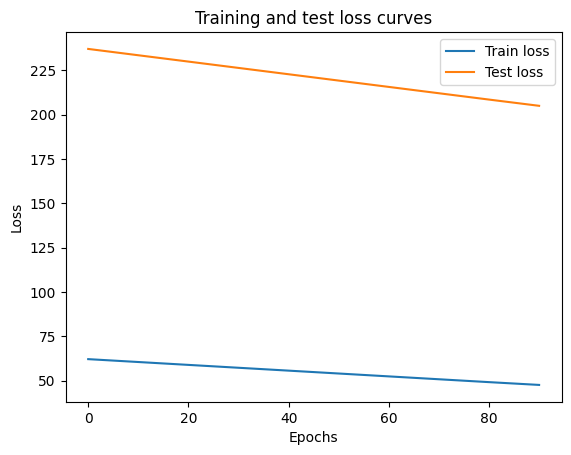

In [281]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

The loss function obtained show a lot of loss in testing and training. Changing the epochs doesn't improve it significantly either.

In [282]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([4.2199]), 'bias': tensor([1.1033])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


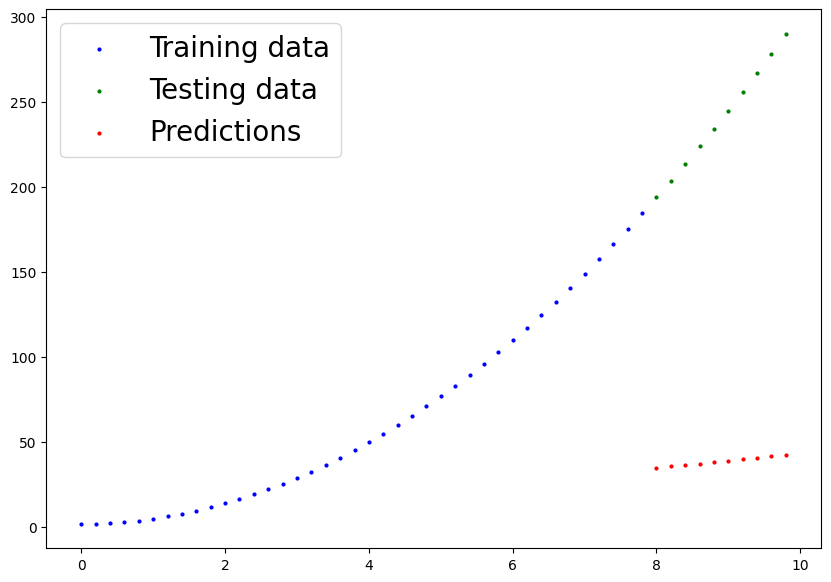

In [283]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Result of Linear Regression
The predicions made by the model is completely off. This can be discerned from the curve where prdicted values represented by the red dots are nowhere close to the green dots (testing data). Unfortunately this is the case even after increasing the epochs.

## Model Accuracy

Our linear model suffers from **underfitting** — it cannot achieve a sufficiently low error even on the training data itself, because it lacks the mathematical capacity to represent a curve. No matter how many times we adjust $w$ and $b$, a straight line will never bend. To understand why, we need to evaluate every available option for scaling the model.

---

### 1. Increasing Epochs (Why It Fails)

Increasing the number of epochs only helps if the model has the **capability** to fit the data but simply needs more time to converge on the optimal parameters.

- **The Problem:** Our linear model has already minimized its error as a straight line within the first few dozen epochs. A linear equation is geometrically constrained — it can only ever produce a straight line. Giving it 10,000 more epochs cannot force that line to curve; it has already found the best possible straight-line fit. The model is not failing because of insufficient training time — it is failing because of insufficient **structure**.

> **Verdict:** More epochs fix *convergence*, not *capacity*. If the model has already converged, extra epochs change nothing.

---

### 2. Increasing Data Points / Dimensions

In machine learning, we can scale our data in two directions: adding more **rows** (samples) or more **columns** (features/dimensions).

- **Adding more rows (samples):** If we add 1,000 more data points along the same curve, the linear model will still draw a straight line through the middle of them. The structural shape mismatch remains regardless of how many points we add — more samples cannot change the shape of the model's output.

- **Adding more columns (new independent features):** If we introduce an entirely new type of independently collected data — for example, if $x$ represents house size, adding a column for *number of bedrooms* — we give the model more context to make better predictions. This can genuinely improve accuracy, but only when those new features are real, independently meaningful measurements.

> **Verdict:** More samples alone will not fix a structural shape mismatch. New independent features can help, but only when real new data exists — not when we only have one variable $x$.

---

### 3. Increasing Parameters (The Gateway to Polynomial Regression)

This is where the real breakthrough happens. Our current model has only **two parameters** — one weight and one bias:

$$\hat{y} = w_1 x + b$$

To model a curve, the model needs more **capacity**, which means more parameters. But since we only have one input variable $x$, where do these extra parameters come from? We **engineer new dimensions mathematically** from our existing data by raising $x$ to higher powers.

#### Introducing $x^2$: A Quadratic Model

By adding a second weight $w_2$ attached to $x^2$, our equation becomes:

$$\hat{y} = w_1 x + w_2 x^2 + b$$

Now the model has 3 parameters and the freedom to form a **parabola** — a single U-shaped or inverted U-shaped curve — rather than a straight line.

#### Generalizing: The Polynomial Equation

We can extend this further by adding $x^3$, $x^4$, and so on. The general form of a degree-$n$ polynomial regression model is:

$$\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + \cdots + w_n x^n + b$$

Each additional power of $x$ introduces a new parameter, and each new parameter gives the model more flexibility. A useful rule of thumb: **the number of bends (turning points) in the curve equals the degree minus one**. A degree-2 model can have 1 bend; a degree-3 model can have 2 bends, and so on.

> **Verdict:** More parameters via higher-degree features → increased model capacity → the model can now curve to fit our data.

---

### ⚠️ A Critical Warning: Overfitting

Increasing the polynomial degree is powerful, but it comes with a risk. Push the degree too high and the model stops learning the underlying pattern — it starts memorizing the noise in the training data instead. This is called **overfitting**: the model performs near-perfectly on training data but fails badly on new, unseen data.

The goal is to find the right degree that captures the true shape of the data without chasing every small fluctuation. This balance between underfitting and overfitting is one of the central challenges of machine learning.

---

### From Linear to Polynomial Regression

It is important to note that despite producing curves, **Polynomial Regression is still considered a linear model** — it is linear *in its parameters* ($w_1, w_2, \ldots, w_n$). The weights are estimated in exactly the same way as in linear regression. What changes is the *geometric shape* of the output, which transitions from a rigid straight line into a flexible curve.

| Model | Equation | Parameters | Bends possible | Shape |
|---|---|---|---|---|
| Linear | $\hat{y} = w_1 x + b$ | 2 | 0 | Straight line |
| Quadratic (Degree 2) | $\hat{y} = w_1 x + w_2 x^2 + b$ | 3 | 1 | Parabola (U or ∩) |
| Cubic (Degree 3) | $\hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$ | 4 | 2 | S-curve or wave |
| Degree $n$ | $\hat{y} = \sum_{i=1}^{n} w_i x^i + b$ | $n+1$ | $n-1$ | Flexible curve |

By mathematically transforming our single input $x$ into higher-degree dimensions ($x^2, x^3, \ldots$), we equip the model with the vocabulary to describe curves — transitioning our project from **Linear Regression** into **Polynomial Regression**.

### Polynomial Regression

In [284]:
import torch
from torch import nn
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights_a = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.weights_b =  nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))


    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights_a * x**2 + self.weights_b * x +self.bias # <- this is the linear regression formula (y = m*x + b)

In [285]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [286]:
print(model_0.weights_a.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [287]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

In [288]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


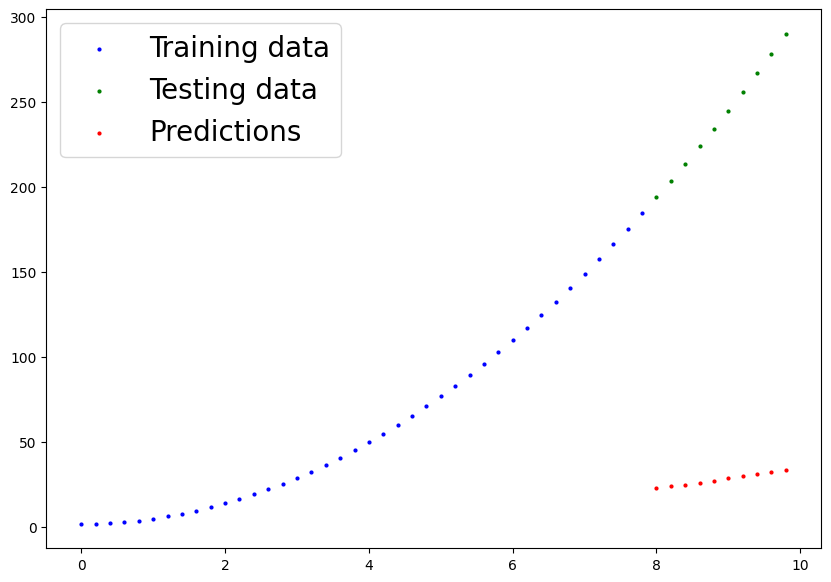

In [289]:
plot_predictions(predictions=y_preds)

## Loss Function Selection

In [290]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [291]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725950598716736 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113582611084 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148272514343262 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227549910545349 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

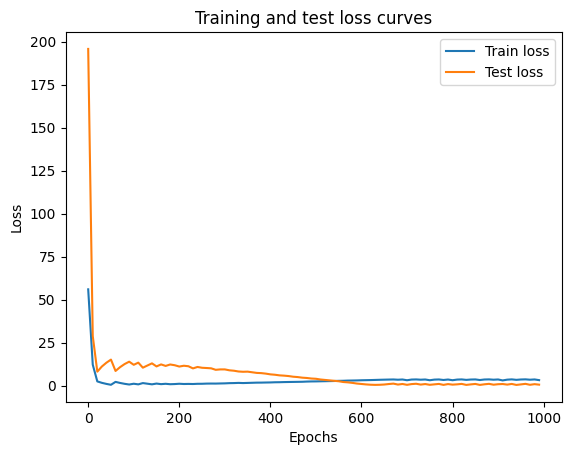

In [292]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [293]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights_a': tensor([2.7001]), 'weights_b': tensor([0.8235]), 'bias': tensor([1.4460])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


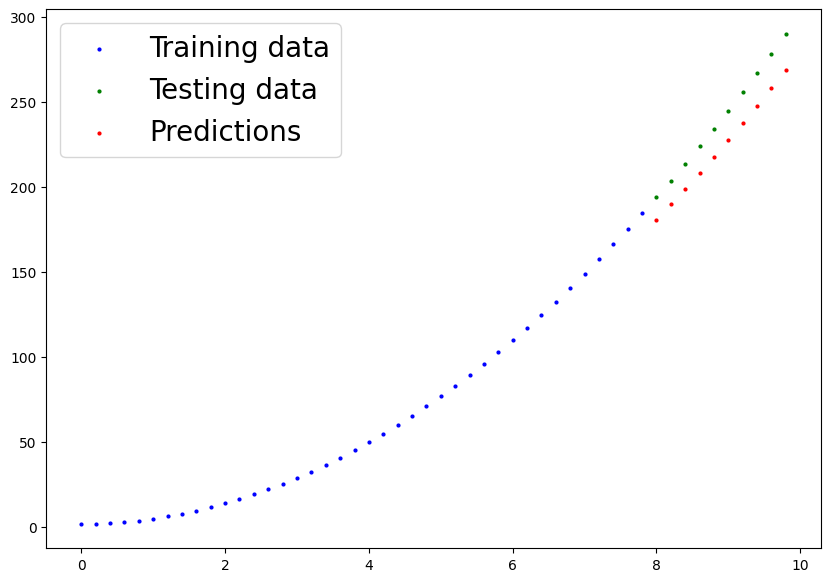

In [294]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)